# Experiment 1: Mapping the Aesthetic Subspace in Qwen3-8B

**Research Question**: Do aesthetic concepts (beauty, elegance, harmony, ugliness, crudeness) occupy a coherent linear subspace in the model's activation space?

## Method
1. **Contrastive Prompt Pairs** — 5 domains (visual, auditory, literary, design, gustatory), positive/negative/neutral
2. **Activation Collection** — Forward each prompt, extract all-layer activations
3. **Aesthetic Direction Extraction** — `mean(positive) - mean(negative)` per layer
4. **PCA Analysis** — Find dominant dimensions of the aesthetic subspace
5. **Validation** — Held-out classification (ROC-AUC), cross-domain transfer
6. **Logit Lens** — Track aesthetic token emergence across layers
7. **Steering Test** — Apply aesthetic direction vector to verify causal effect

## 1. Setup & Environment

In [1]:
import neuroscope
import numpy as np
import sys, os, time, json, warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold

# --- Matplotlib font config ---
_cjk_font_dir = '/usr/share/fonts/opentype/noto/'
for _fp in fm.findSystemFonts([_cjk_font_dir]):
    fm.fontManager.addfont(_fp)
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

sys.path.insert(0, '/workspace/Test_bench')
import utils

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
os.environ['TORCH_HOME'] = '/workspace/Data/torch_cache'

print(f'NeuroScope {neuroscope.__version__}, CUDA: {neuroscope.cuda_available()}')

NeuroScope 1.2.3, CUDA: True


In [2]:
# --- Config ---
MODEL_PATH = '/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf'
OUTPUT_DIR = Path('/workspace/Data/aesthetic_experiment')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NOTHINK_SUFFIX = '<think>\n\n</think>\n\n'
SEED = 42
np.random.seed(SEED)

print(f'Output: {OUTPUT_DIR}')

Output: /workspace/Data/aesthetic_experiment


## 2. Load Engine

In [3]:
engine = neuroscope.Engine(
    model_path=MODEL_PATH,
    n_ctx=4096,       # Single forward only, no batch — 4096 is enough
    n_gpu_layers=-1,
    n_seq_max=1,      # Only single-sequence inference needed
    seed=SEED,
    temperature=0.7,
    top_p=0.95,
    top_k=40,
    verbose=True,
    disable_flash_attention=False
)

info = engine.model_info
N_LAYERS = info.n_layers
N_EMBD = info.n_embd
print(f'Model: {info.name} | Layers: {N_LAYERS} | Hidden: {N_EMBD} | Vocab: {info.n_vocab}')

Model: Qwen3 8B Awq Compatible Instruct | Layers: 36 | Hidden: 4096 | Vocab: 151936
[CoreEngine] Loading model: /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf
[CoreEngine] Preparing logit lens resources:
  - Tensor shape: [151936, 4096]
  - Tensor type: q6_K
  - Quantized weights (q6_K) dequantized to FP16
  - FP16 weights allocated on GPU: 1187 MB
  - Logit lens ready for all model types!
[CoreEngine] Model loaded: Qwen3 8B Awq Compatible Instruct
  Architecture: qwen (qwen3)
  Layers: 36, Hidden: 4096
  Heads: 32 Q, 8 KV (GQA)


ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 110986128
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 110986128
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 108384 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           genera

936
print_info: n_merges              = 151387
print_info: BOS token             = 151643 '<|endoftext|>'
print_info: EOS token             = 151645 '<|im_end|>'
print_info: EOT token             = 151645 '<|im_end|>'
print_info: PAD token             = 151643 '<|endoftext|>'
print_info: LF token              = 198 'Ċ'
print_info: FIM PRE token         = 151659 '<|fim_prefix|>'
print_info: FIM SUF token         = 151661 '<|fim_suffix|>'
print_info: FIM MID token         = 151660 '<|fim_middle|>'
print_info: FIM PAD token         = 151662 '<|fim_pad|>'
print_info: FIM REP token         = 151663 '<|repo_name|>'
print_info: FIM SEP token         = 151664 '<|file_sep|>'
print_info: EOG token             = 128247 '</s>'
print_info: EOG token             = 151643 '<|endoftext|>'
print_info: EOG token             = 151645 '<|im_end|>'
print_info: EOG token             = 151662 '<|fim_pad|>'
print_info: EOG token             = 151663 '<|repo_name|>'
print_info: EOG token             = 151664 '

## 3. Contrastive Prompt Dataset

Each domain has **positive** (aesthetically rich), **negative** (aesthetically poor), and **neutral** prompts.

Key design principles:
- Prompts ask the model to **describe** (not evaluate) — we want the model's internal aesthetic representation, not its explicit judgment
- Matched length and structure between positive/negative pairs
- English prompts to maximize Qwen3's generation quality

In [4]:
# ============================================================
# Contrastive Aesthetic Prompt Dataset
# Format: (positive, negative) pairs grouped by domain
# ============================================================

AESTHETIC_PROMPTS = {
    'visual': [
        ('Describe a breathtaking sunset over a calm ocean, with golden light reflecting on the waves',
         'Describe a gray overcast sky above a muddy drainage ditch next to a highway'),
        ('Describe an elegant marble sculpture in a Renaissance gallery, with soft natural light',
         'Describe a broken concrete block lying in an abandoned construction site'),
        ('Describe a mountain landscape covered in fresh snow, with pine forests and a frozen lake',
         'Describe a flat empty parking lot with cracked asphalt and oil stains'),
        ('Describe a field of lavender in Provence at golden hour, with bees and butterflies',
         'Describe a patch of dead weeds growing through cracks in an industrial yard'),
        ('Describe the night sky in a remote desert, filled with stars and the Milky Way',
         'Describe the view from a small window facing a brick wall, with a single streetlight'),
        ('Describe a Japanese garden with a koi pond, stone bridge, and blooming cherry trees',
         'Describe a neglected backyard with an overturned trash can and a broken fence'),
        ('Describe the interior of a Gothic cathedral with stained glass windows and vaulted ceilings',
         'Describe the interior of a fluorescent-lit warehouse with concrete floors and metal shelving'),
        ('Describe a tropical waterfall cascading into a crystal-clear pool surrounded by ferns',
         'Describe a leaking fire hydrant on a sidewalk creating a puddle of dirty water'),
        ('Describe an autumn forest path with red and gold leaves forming a colorful canopy',
         'Describe a narrow alley between two buildings with dumpsters and puddles'),
        ('Describe the reflection of a full moon on a perfectly still lake at midnight',
         'Describe fluorescent lights reflecting on a wet linoleum floor in a hospital corridor'),
    ],
    'auditory': [
        ('Describe the sound of a solo cello playing a melancholic melody in an empty concert hall',
         'Describe the sound of a car alarm going off repeatedly in a parking garage'),
        ('Describe the sound of rain gently falling on leaves in a quiet forest',
         'Describe the sound of heavy machinery operating at a construction site'),
        ('Describe a choir singing in harmony inside a stone chapel, their voices echoing',
         'Describe the sound of a broken speaker playing distorted static noise in a store'),
        ('Describe the sound of ocean waves rhythmically washing over a sandy beach at dawn',
         'Describe the sound of traffic on a busy highway during rush hour'),
        ('Describe the tinkling of a music box playing a lullaby in a quiet nursery',
         'Describe the buzzing of a fluorescent light tube in a basement room'),
        ('Describe a jazz pianist improvising a gentle piece in a dimly lit club',
         'Describe someone dragging a metal chair across a tile floor'),
        ('Describe wind chimes making soft sounds in a gentle summer breeze',
         'Describe an air conditioning unit rattling and humming loudly'),
        ('Describe a nightingale singing at twilight in a flowering garden',
         'Describe crows cawing near an overflowing garbage bin'),
        ('Describe the gentle plucking of a classical guitar by a fireside',
         'Describe the screeching of a subway train braking at a platform'),
        ('Describe a string quartet playing Mozart in a candlelit room',
         'Describe a power drill operating inside a small apartment'),
    ],
    'literary': [
        ('Write a short, beautiful description of the first snow of winter falling on a village',
         'Write a short, plain description of slush accumulating on a roadside'),
        ('Write an elegant opening sentence for a novel about a wanderer finding home',
         'Write an opening sentence for a manual about filing tax returns'),
        ('Describe the feeling of reading a beloved poem for the hundredth time',
         'Describe the feeling of reading the terms and conditions of a software agreement'),
        ('Write a lyrical description of two old friends reuniting after decades apart',
         'Write a factual description of two people standing in a queue at a government office'),
        ('Describe the beauty of a handwritten love letter found in an old book',
         'Describe a printed receipt found in a jacket pocket'),
        ('Write a poetic description of moonlight entering through a window onto a sleeping child',
         'Write a description of a light switch being turned on in a bathroom'),
        ('Describe the magic of a child hearing a fairy tale for the first time',
         'Describe a child hearing safety instructions on an airplane'),
        ('Write an evocative description of the smell of old books in a library',
         'Write a description of the smell of cleaning products in a restroom'),
        ('Describe the elegance of a dancer performing a solo on an empty stage',
         'Describe someone walking on a treadmill at a gym'),
        ('Write a beautiful paragraph about the silence between two people who understand each other',
         'Write a paragraph about the silence during a long elevator ride with a stranger'),
    ],
    'design': [
        ('Describe the elegance of a minimalist Scandinavian living room with clean lines and natural light',
         'Describe a cluttered storage room filled with cardboard boxes and old furniture'),
        ('Describe a hand-crafted ceramic tea set with subtle glaze variations and organic shapes',
         'Describe a stack of disposable foam cups next to a coffee machine'),
        ('Describe the flowing lines of a classic Porsche 911 in silver',
         'Describe a dented minivan with faded paint in a supermarket parking lot'),
        ('Describe a perfectly typeset page from a fine letterpress edition of poetry',
         'Describe a photocopied flyer with clip art and Comic Sans text'),
        ('Describe the proportions and harmony of the Golden Gate Bridge at sunset',
         'Describe a highway overpass made of precast concrete segments'),
        ('Describe a winding garden path made of hand-laid cobblestone with moss between the joints',
         'Describe a straight concrete sidewalk with expansion joints every six feet'),
        ('Describe a tailor-made suit with impeccable stitching and a perfect drape',
         'Describe an ill-fitting polyester uniform hanging in a locker room'),
        ('Describe the grace of a traditional Chinese silk fan with painted mountains',
         'Describe a plastic hand-fan with a company logo on it'),
        ('Describe a Frank Lloyd Wright house seamlessly integrated into a hillside landscape',
         'Describe a prefab metal shed placed on a concrete slab in a flat lot'),
        ('Describe the artistry of a stained glass rose window in a medieval cathedral',
         'Describe a glass panel in a bus shelter with graffiti scratched into it'),
    ],
    'gustatory': [
        ('Describe the experience of tasting a perfectly crafted French pastry with delicate layers',
         'Describe the experience of eating a stale vending machine sandwich'),
        ('Describe a glass of aged Bordeaux wine, its aroma, color, and smooth finish',
         'Describe a cup of lukewarm instant coffee from a paper cup'),
        ('Describe the flavors of a traditional Japanese kaiseki course with seasonal ingredients',
         'Describe the flavors of a microwaved frozen dinner with rubbery chicken'),
        ('Describe freshly baked sourdough bread, its golden crust cracking as you tear it open',
         'Describe a slice of white bread from a plastic bag, slightly stale'),
        ('Describe a platter of fresh sushi, each piece artfully arranged with wasabi and ginger',
         'Describe a tray of gas station hot dogs rotating under a heat lamp'),
        ('Describe the experience of tasting honey straight from a comb on a warm summer day',
         'Describe the experience of tasting artificial sweetener dissolved in tap water'),
        ('Describe a rich, dark chocolate truffle melting slowly on the tongue',
         'Describe a piece of waxy candy with an artificial flavor'),
        ('Describe the aroma and taste of a Moroccan tagine with saffron and preserved lemons',
         'Describe the taste of overcooked instant noodles with too much salt'),
        ('Describe the delicate flavors of a Chinese dim sum brunch with hand-folded dumplings',
         'Describe the taste of a soggy microwave burrito from a convenience store'),
        ('Describe a perfect espresso: dark crema, rich aroma, bittersweet complexity',
         'Describe burnt coffee sitting in a pot since morning, reheated in a microwave'),
    ]
}

# Neutral prompts (no aesthetic valence)
NEUTRAL_PROMPTS = [
    'Describe the layout of a standard office desk',
    'Describe the steps to change a car tire',
    'Describe the process of boiling water in a kettle',
    'Describe what happens when you press a doorbell',
    'Describe the contents of a typical first-aid kit',
    'Describe the parts of a standard bicycle',
    'Describe the procedure for washing hands',
    'Describe the structure of a simple HTML webpage',
    'Describe the components inside a desktop computer',
    'Describe the process of mailing a letter at a post office',
    'Describe what a thermometer measures and how it works',
    'Describe the steps to sharpen a pencil',
    'Describe the layout of a standard chess board',
    'Describe the process of tying a shoelace',
    'Describe the parts of an analog clock',
    'Describe the steps for setting an alarm on a phone',
    'Describe how a paper stapler works',
    'Describe the contents of a kitchen drawer',
    'Describe the procedure for parallel parking a car',
    'Describe how a zipper mechanism works',
]

# Collect all prompts
all_positive = []
all_negative = []
all_domains = []

for domain, pairs in AESTHETIC_PROMPTS.items():
    for pos, neg in pairs:
        all_positive.append(pos)
        all_negative.append(neg)
        all_domains.append(domain)

n_pairs = len(all_positive)
domains = list(AESTHETIC_PROMPTS.keys())
print(f'Total contrastive pairs: {n_pairs}')
print(f'Domains: {domains} ({[sum(1 for d in all_domains if d==dom) for dom in domains]} per domain)')
print(f'Neutral prompts: {len(NEUTRAL_PROMPTS)}')

Total contrastive pairs: 50
Domains: ['visual', 'auditory', 'literary', 'design', 'gustatory'] ([10, 10, 10, 10, 10] per domain)
Neutral prompts: 20


## 4. Collect Activations

For each prompt, we:
1. Apply chat template (user role) + nothink suffix
2. Run `engine.forward()` (prefill only — no generation needed)
3. Extract activations from all layers via `engine.get_all_activations()`

This gives us the model's **internal state** after reading the prompt, before generating any output.

In [5]:
def collect_activations(engine, prompts, desc='Collecting'):
    """Forward each prompt and collect all-layer activations.
    
    Returns:
        np.ndarray of shape [n_prompts, n_layers, n_embd]
    """
    all_acts = []
    for prompt_text in tqdm(prompts, desc=desc):
        messages = [{'role': 'user', 'content': prompt_text}]
        templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX
        engine.reset()
        engine.forward(templated, add_special=True)
        # get_all_activations returns list of n_layers arrays, each [n_embd]
        acts = engine.get_all_activations()  # list[np.ndarray]
        all_acts.append(np.array(acts))      # [n_layers, n_embd]
    return np.array(all_acts)                 # [n_prompts, n_layers, n_embd]

print('Activation collector ready.')

Activation collector ready.


In [6]:
# Collect positive, negative, and neutral activations
t0 = time.time()

print('=== Collecting POSITIVE (aesthetic) activations ===')
acts_positive = collect_activations(engine, all_positive, desc='Positive')

print('\n=== Collecting NEGATIVE (non-aesthetic) activations ===')
acts_negative = collect_activations(engine, all_negative, desc='Negative')

print('\n=== Collecting NEUTRAL activations ===')
acts_neutral = collect_activations(engine, NEUTRAL_PROMPTS, desc='Neutral')

elapsed = time.time() - t0
print(f'\nDone! Shapes: positive={acts_positive.shape}, negative={acts_negative.shape}, neutral={acts_neutral.shape}')
print(f'Time: {elapsed:.1f}s ({elapsed/60:.1f}min)')

=== Collecting POSITIVE (aesthetic) activations ===


Positive: 100%|██████████| 50/50 [00:02<00:00, 20.67it/s]



=== Collecting NEGATIVE (non-aesthetic) activations ===


Negative: 100%|██████████| 50/50 [00:02<00:00, 21.40it/s]



=== Collecting NEUTRAL activations ===


Neutral: 100%|██████████| 20/20 [00:00<00:00, 21.72it/s]


Done! Shapes: positive=(50, 36, 4096), negative=(50, 36, 4096), neutral=(20, 36, 4096)
Time: 5.7s (0.1min)


In [7]:
# Save raw activations
np.savez_compressed(
    OUTPUT_DIR / 'raw_activations.npz',
    positive=acts_positive,
    negative=acts_negative,
    neutral=acts_neutral,
    domains=np.array(all_domains),
    prompts_positive=np.array(all_positive),
    prompts_negative=np.array(all_negative),
    prompts_neutral=np.array(NEUTRAL_PROMPTS),
)
print(f'Saved to {OUTPUT_DIR / "raw_activations.npz"}')
print(f'File size: {(OUTPUT_DIR / "raw_activations.npz").stat().st_size / 1e6:.1f} MB')

Saved to /workspace/Data/aesthetic_experiment/raw_activations.npz
File size: 65.7 MB


## 5. Extract Aesthetic Direction Vectors

The **aesthetic direction** at each layer is simply:
$$\vec{d}_{\text{aesthetic}}^{(l)} = \overline{\mathbf{a}}_{\text{positive}}^{(l)} - \overline{\mathbf{a}}_{\text{negative}}^{(l)}$$

This is the direction in activation space that separates "beautiful" from "ugly" prompts.

In [8]:
# Compute mean activations per group, per layer
mean_positive = acts_positive.mean(axis=0)  # [n_layers, n_embd]
mean_negative = acts_negative.mean(axis=0)
mean_neutral  = acts_neutral.mean(axis=0)

# Aesthetic direction vector per layer
aesthetic_direction = mean_positive - mean_negative  # [n_layers, n_embd]

# Normalize to unit vectors for cosine-based analysis
aesthetic_direction_norm = aesthetic_direction / (np.linalg.norm(aesthetic_direction, axis=1, keepdims=True) + 1e-10)

print(f'Aesthetic direction shape: {aesthetic_direction.shape}')
print(f'Direction magnitude per layer (L2 norm):')
norms = np.linalg.norm(aesthetic_direction, axis=1)
for i in range(0, N_LAYERS, 4):
    print(f'  Layers {i:2d}-{min(i+3, N_LAYERS-1):2d}: {norms[i:i+4]}')

Aesthetic direction shape: (36, 4096)
Direction magnitude per layer (L2 norm):
  Layers  0- 3: [0.28921932 0.43283302 0.5499109  0.96735173]
  Layers  4- 7: [1.1662515 1.5359384 1.7925245 1.9890255]
  Layers  8-11: [2.838677  3.7860868 3.678519  3.867002 ]
  Layers 12-15: [4.5002756 5.24301   5.399639  6.06749  ]
  Layers 16-19: [ 7.219753  8.506896 11.018198 13.393608]
  Layers 20-23: [15.287891 20.608166 24.610872 31.458176]
  Layers 24-27: [42.443714 50.623795 62.84505  76.23844 ]
  Layers 28-31: [ 90.2018   100.437965 120.61786  135.39789 ]
  Layers 32-35: [149.74286 162.14398 183.77942 202.12773]


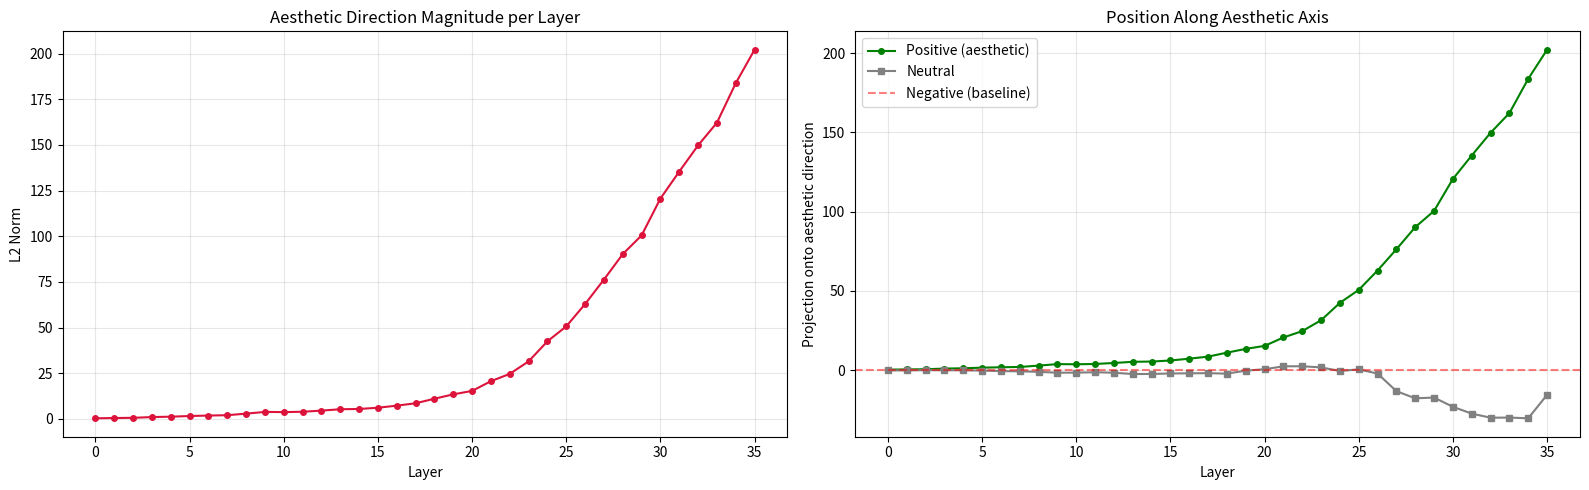

In [9]:
# Plot: Aesthetic direction magnitude across layers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Direction magnitude
axes[0].plot(norms, 'o-', c='crimson', markersize=4)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('L2 Norm')
axes[0].set_title('Aesthetic Direction Magnitude per Layer')
axes[0].grid(True, alpha=0.3)

# Right: Where is neutral relative to positive/negative?
# Project neutral onto aesthetic direction
neutral_proj = np.array([
    np.dot(mean_neutral[l] - mean_negative[l], aesthetic_direction_norm[l])
    for l in range(N_LAYERS)
])
positive_proj = np.array([
    np.dot(mean_positive[l] - mean_negative[l], aesthetic_direction_norm[l])
    for l in range(N_LAYERS)
])

axes[1].plot(positive_proj, 'o-', c='green', markersize=4, label='Positive (aesthetic)')
axes[1].plot(neutral_proj, 's-', c='gray', markersize=4, label='Neutral')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5, label='Negative (baseline)')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Projection onto aesthetic direction')
axes[1].set_title('Position Along Aesthetic Axis')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aesthetic_direction_magnitude.png', dpi=150)
plt.show()

## 6. PCA Analysis — Aesthetic Subspace Structure

Do the aesthetic differences span a **single direction** or a **multi-dimensional subspace**?

In [10]:
def pca_at_layer(acts_pos, acts_neg, layer, n_components=10):
    """Run PCA on the difference vectors at a specific layer."""
    # Difference per pair
    diffs = acts_pos[:, layer, :] - acts_neg[:, layer, :]  # [n_pairs, n_embd]
    pca = PCA(n_components=min(n_components, diffs.shape[0]))
    pca.fit(diffs)
    return pca

# Analyze PCA at key layers: early, mid, late
analysis_layers = [0, N_LAYERS//4, N_LAYERS//2, 3*N_LAYERS//4, N_LAYERS-2, N_LAYERS-1]

pca_results = {}
print(f'PCA Analysis (explained variance ratio of top components):')
print(f'{"Layer":>6} | {"PC1":>7} | {"PC2":>7} | {"PC3":>7} | {"Top-3 Sum":>10} | {"Top-5 Sum":>10}')
print('-' * 65)

for layer in analysis_layers:
    pca = pca_at_layer(acts_positive, acts_negative, layer)
    pca_results[layer] = pca
    evr = pca.explained_variance_ratio_
    print(f'{layer:>6} | {evr[0]:>7.3f} | {evr[1]:>7.3f} | {evr[2]:>7.3f} | {sum(evr[:3]):>10.3f} | {sum(evr[:5]):>10.3f}')

PCA Analysis (explained variance ratio of top components):
 Layer |     PC1 |     PC2 |     PC3 |  Top-3 Sum |  Top-5 Sum
-----------------------------------------------------------------
     0 |   0.119 |   0.099 |   0.088 |      0.307 |      0.431
     9 |   0.098 |   0.073 |   0.064 |      0.235 |      0.338
    18 |   0.160 |   0.098 |   0.062 |      0.321 |      0.407
    27 |   0.173 |   0.116 |   0.063 |      0.352 |      0.457
    34 |   0.140 |   0.085 |   0.071 |      0.296 |      0.409
    35 |   0.157 |   0.106 |   0.067 |      0.330 |      0.438


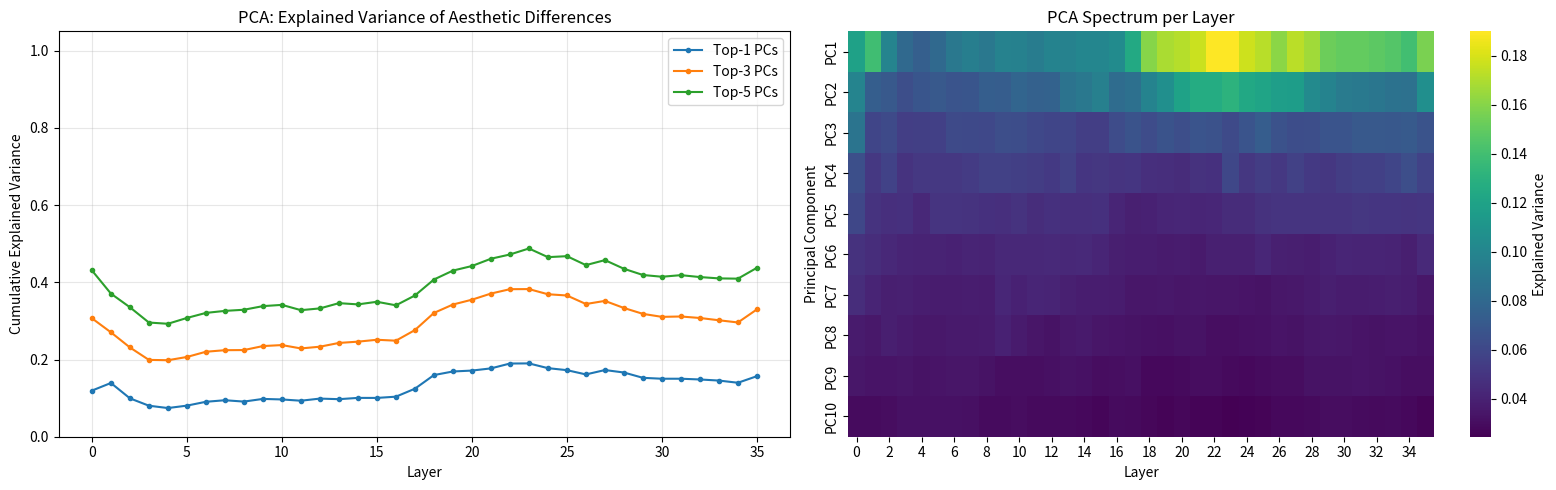

In [11]:
# Full PCA sweep across ALL layers
explained_var_all = []  # [n_layers, n_components]
for layer in range(N_LAYERS):
    pca = pca_at_layer(acts_positive, acts_negative, layer)
    explained_var_all.append(pca.explained_variance_ratio_)

explained_var_all = np.array(explained_var_all)  # [n_layers, 10]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Top-k explained variance across layers
for k in [1, 3, 5]:
    axes[0].plot(explained_var_all[:, :k].sum(axis=1), 'o-', markersize=3, label=f'Top-{k} PCs')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA: Explained Variance of Aesthetic Differences')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Right: Heatmap of top-10 PCs across layers
sns.heatmap(explained_var_all.T, cmap='viridis', ax=axes[1],
            yticklabels=[f'PC{i+1}' for i in range(explained_var_all.shape[1])],
            cbar_kws={'label': 'Explained Variance'})
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Principal Component')
axes[1].set_title('PCA Spectrum per Layer')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_analysis.png', dpi=150)
plt.show()

## 7. Held-out Classification — Can We Predict Aesthetic Valence?

If the aesthetic direction is real, we should be able to classify held-out prompts as positive or negative just by **projecting onto the aesthetic direction**.

We use 5-fold cross-validation to avoid overfitting.

In [12]:
# Build classification dataset: project each sample onto aesthetic direction
# Label: 1 = positive, 0 = negative

def classify_at_layer(acts_pos, acts_neg, layer, n_folds=5):
    """Train/test logistic regression on aesthetic direction at one layer."""
    X = np.vstack([acts_pos[:, layer, :], acts_neg[:, layer, :]])  # [2*n_pairs, n_embd]
    y = np.array([1]*len(acts_pos) + [0]*len(acts_neg))
    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    aucs, accs = [], []
    
    for train_idx, test_idx in skf.split(X, y):
        clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
        clf.fit(X[train_idx], y[train_idx])
        y_prob = clf.predict_proba(X[test_idx])[:, 1]
        y_pred = clf.predict(X[test_idx])
        aucs.append(roc_auc_score(y[test_idx], y_prob))
        accs.append(accuracy_score(y[test_idx], y_pred))
    
    return np.mean(aucs), np.std(aucs), np.mean(accs), np.std(accs)

# Classify at every layer
layer_aucs = []
layer_accs = []
print(f'{"Layer":>6} | {"AUC":>12} | {"Accuracy":>12}')
print('-' * 40)

for layer in range(N_LAYERS):
    auc_mean, auc_std, acc_mean, acc_std = classify_at_layer(acts_positive, acts_negative, layer)
    layer_aucs.append((auc_mean, auc_std))
    layer_accs.append((acc_mean, acc_std))
    if layer % 4 == 0 or layer == N_LAYERS - 1:
        print(f'{layer:>6} | {auc_mean:.3f}±{auc_std:.3f} | {acc_mean:.3f}±{acc_std:.3f}')

layer_aucs = np.array(layer_aucs)
layer_accs = np.array(layer_accs)

 Layer |          AUC |     Accuracy
----------------------------------------
     0 | 0.938±0.024 | 0.850±0.032
     4 | 0.994±0.008 | 0.960±0.020
     8 | 0.990±0.015 | 0.960±0.037
    12 | 0.992±0.010 | 0.950±0.055
    16 | 1.000±0.000 | 1.000±0.000
    20 | 1.000±0.000 | 1.000±0.000
    24 | 1.000±0.000 | 1.000±0.000
    28 | 1.000±0.000 | 1.000±0.000
    32 | 1.000±0.000 | 1.000±0.000
    35 | 1.000±0.000 | 1.000±0.000


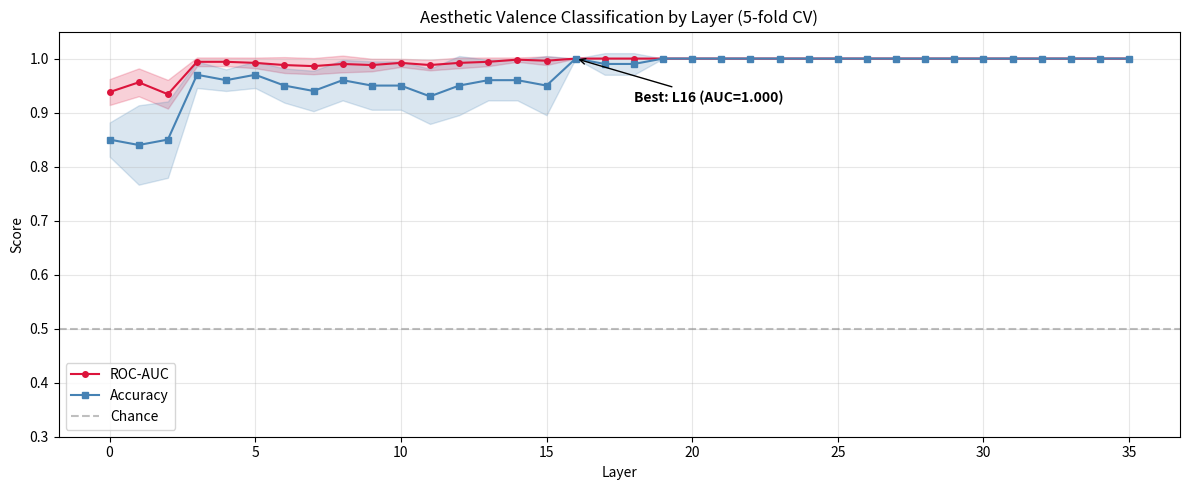


Best classification layer: 16
  AUC: 1.000 ± 0.000
  Acc: 1.000 ± 0.000


In [13]:
# Plot classification results
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(layer_aucs[:, 0], 'o-', c='crimson', markersize=4, label='ROC-AUC')
ax.fill_between(range(N_LAYERS),
                layer_aucs[:, 0] - layer_aucs[:, 1],
                layer_aucs[:, 0] + layer_aucs[:, 1],
                alpha=0.2, color='crimson')
ax.plot(layer_accs[:, 0], 's-', c='steelblue', markersize=4, label='Accuracy')
ax.fill_between(range(N_LAYERS),
                layer_accs[:, 0] - layer_accs[:, 1],
                layer_accs[:, 0] + layer_accs[:, 1],
                alpha=0.2, color='steelblue')

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.set_xlabel('Layer')
ax.set_ylabel('Score')
ax.set_title('Aesthetic Valence Classification by Layer (5-fold CV)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.3, 1.05)

# Mark best layer
best_cls_layer = np.argmax(layer_aucs[:, 0])
ax.annotate(f'Best: L{best_cls_layer} (AUC={layer_aucs[best_cls_layer, 0]:.3f})',
            xy=(best_cls_layer, layer_aucs[best_cls_layer, 0]),
            xytext=(best_cls_layer + 2, layer_aucs[best_cls_layer, 0] - 0.08),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classification_by_layer.png', dpi=150)
plt.show()

print(f'\nBest classification layer: {best_cls_layer}')
print(f'  AUC: {layer_aucs[best_cls_layer, 0]:.3f} ± {layer_aucs[best_cls_layer, 1]:.3f}')
print(f'  Acc: {layer_accs[best_cls_layer, 0]:.3f} ± {layer_accs[best_cls_layer, 1]:.3f}')

## 8. Cross-Domain Transfer

**Key question**: Is the aesthetic direction universal, or domain-specific?

Train on 4 domains, test on the held-out 5th. If AUC remains high → the aesthetic subspace generalizes across sensory modalities.

In [14]:
# Cross-domain transfer: leave-one-domain-out
domain_array = np.array(all_domains)

def cross_domain_classify(acts_pos, acts_neg, domains, layer):
    """Leave-one-domain-out cross-validation."""
    unique_domains = sorted(set(domains))
    results = {}
    
    for held_out in unique_domains:
        train_mask = np.array([d != held_out for d in domains])
        test_mask = ~train_mask
        
        X_train = np.vstack([acts_pos[train_mask, layer, :], acts_neg[train_mask, layer, :]])
        y_train = np.array([1]*train_mask.sum() + [0]*train_mask.sum())
        
        X_test = np.vstack([acts_pos[test_mask, layer, :], acts_neg[test_mask, layer, :]])
        y_test = np.array([1]*test_mask.sum() + [0]*test_mask.sum())
        
        clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
        clf.fit(X_train, y_train)
        y_prob = clf.predict_proba(X_test)[:, 1]
        
        auc = roc_auc_score(y_test, y_prob)
        acc = accuracy_score(y_test, clf.predict(X_test))
        results[held_out] = {'auc': auc, 'acc': acc}
    
    return results

# Run for best classification layer and a few others
transfer_layers = [best_cls_layer, N_LAYERS//4, N_LAYERS//2, 3*N_LAYERS//4, N_LAYERS-2]
transfer_layers = sorted(set(transfer_layers))

print('Cross-Domain Transfer (Leave-One-Domain-Out):')
print(f'{"Layer":>6} | {"visual":>8} | {"auditory":>8} | {"literary":>8} | {"design":>8} | {"gustatory":>9} | {"Mean":>8}')
print('-' * 80)

transfer_results = {}
for layer in transfer_layers:
    res = cross_domain_classify(acts_positive, acts_negative, all_domains, layer)
    transfer_results[layer] = res
    vals = [res[d]['auc'] for d in domains]
    row = ' | '.join(f'{v:>8.3f}' for v in vals)
    print(f'{layer:>6} | {row} | {np.mean(vals):>8.3f}')

Cross-Domain Transfer (Leave-One-Domain-Out):
 Layer |   visual | auditory | literary |   design | gustatory |     Mean
--------------------------------------------------------------------------------
     9 |    1.000 |    1.000 |    1.000 |    1.000 |    0.990 |    0.998
    16 |    1.000 |    1.000 |    1.000 |    1.000 |    1.000 |    1.000
    18 |    1.000 |    1.000 |    1.000 |    1.000 |    1.000 |    1.000
    27 |    1.000 |    1.000 |    1.000 |    1.000 |    1.000 |    1.000
    34 |    1.000 |    1.000 |    1.000 |    1.000 |    1.000 |    1.000


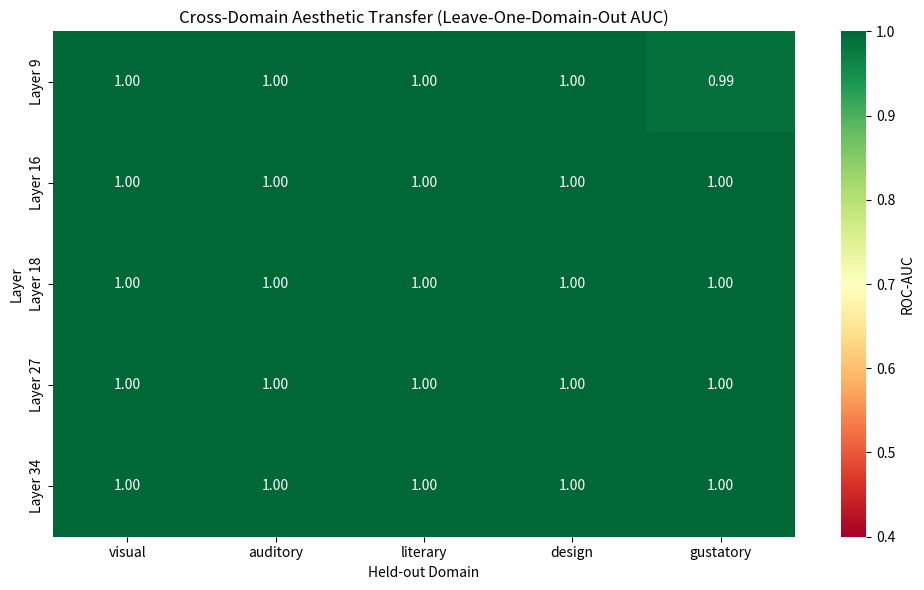

In [15]:
# Heatmap: cross-domain transfer AUC
transfer_matrix = np.array([
    [transfer_results[l][d]['auc'] for d in domains]
    for l in transfer_layers
])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(transfer_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=domains,
            yticklabels=[f'Layer {l}' for l in transfer_layers],
            vmin=0.4, vmax=1.0, ax=ax,
            cbar_kws={'label': 'ROC-AUC'})
ax.set_title('Cross-Domain Aesthetic Transfer (Leave-One-Domain-Out AUC)')
ax.set_xlabel('Held-out Domain')
ax.set_ylabel('Layer')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_domain_transfer.png', dpi=150)
plt.show()

## 9. Per-Domain Aesthetic Directions — Similarity Analysis

Are domain-specific aesthetic directions aligned or orthogonal?

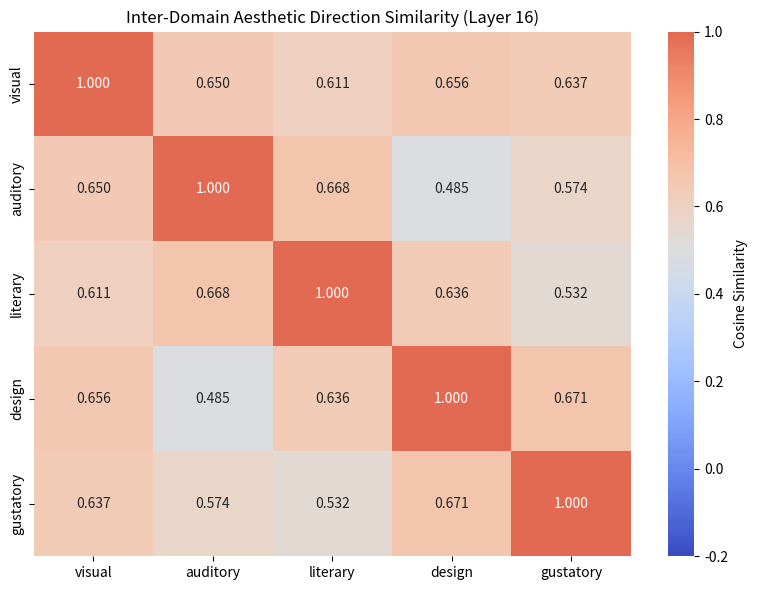


Alignment with global aesthetic direction:
      visual: cosine = 0.8450
    auditory: cosine = 0.8164
    literary: cosine = 0.8490
      design: cosine = 0.8269
   gustatory: cosine = 0.8119


In [16]:
# Extract per-domain aesthetic directions at the best layer
domain_directions = {}
for domain in domains:
    mask = np.array([d == domain for d in all_domains])
    d_pos = acts_positive[mask, best_cls_layer, :].mean(axis=0)
    d_neg = acts_negative[mask, best_cls_layer, :].mean(axis=0)
    direction = d_pos - d_neg
    direction_norm = direction / (np.linalg.norm(direction) + 1e-10)
    domain_directions[domain] = direction_norm

# Cosine similarity matrix between domain directions
sim_matrix = np.zeros((len(domains), len(domains)))
for i, d1 in enumerate(domains):
    for j, d2 in enumerate(domains):
        sim_matrix[i, j] = np.dot(domain_directions[d1], domain_directions[d2])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            xticklabels=domains, yticklabels=domains,
            vmin=-0.2, vmax=1.0, ax=ax, center=0.5,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title(f'Inter-Domain Aesthetic Direction Similarity (Layer {best_cls_layer})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'domain_similarity.png', dpi=150)
plt.show()

# Global vs. domain: how aligned is each domain direction with the global aesthetic direction?
print('\nAlignment with global aesthetic direction:')
for domain in domains:
    sim = np.dot(domain_directions[domain], aesthetic_direction_norm[best_cls_layer])
    print(f'  {domain:>10}: cosine = {sim:.4f}')

## 10. Logit Lens — Aesthetic Concept Emergence

At which layer does the model start predicting aesthetic tokens (beautiful, elegant, ugly, crude)?
We use a representative aesthetic prompt and track token probabilities layer by layer.

In [17]:
# Aesthetic and non-aesthetic target tokens
AESTHETIC_TOKENS = ['beautiful', 'elegant', 'graceful', 'stunning', 'gorgeous',
                    'delicate', 'harmonious', 'serene', 'magnificent', 'exquisite']
NON_AESTHETIC_TOKENS = ['ugly', 'crude', 'hideous', 'bland', 'dull',
                        'plain', 'boring', 'mediocre', 'ordinary', 'common']

# Get token IDs for tracking
def get_token_ids(engine, words):
    """Get tokenizer IDs for individual words. Uses the first token if multi-token."""
    ids = {}
    for w in words:
        tokens = engine.tokenize(w)
        if tokens:
            ids[w] = tokens[-1]  # use last token (the actual word, not leading space)
    return ids

aesthetic_token_ids = get_token_ids(engine, AESTHETIC_TOKENS)
non_aesthetic_token_ids = get_token_ids(engine, NON_AESTHETIC_TOKENS)

print('Aesthetic token IDs:')
for w, tid in aesthetic_token_ids.items():
    print(f'  {w:>15} → token_id {tid}')
print('\nNon-aesthetic token IDs:')
for w, tid in non_aesthetic_token_ids.items():
    print(f'  {w:>15} → token_id {tid}')

Aesthetic token IDs:
        beautiful → token_id 86944
          elegant → token_id 58802
         graceful → token_id 1262
         stunning → token_id 11216
         gorgeous → token_id 782
         delicate → token_id 8463
       harmonious → token_id 1223
           serene → token_id 1952
      magnificent → token_id 36143
        exquisite → token_id 32424

Non-aesthetic token IDs:
             ugly → token_id 398
            crude → token_id 793
          hideous → token_id 782
            bland → token_id 1933
             dull → token_id 617
            plain → token_id 20772
           boring → token_id 5503
         mediocre → token_id 62418
         ordinary → token_id 21031
           common → token_id 5464


In [18]:
# Run logit lens on a positive aesthetic prompt
test_aesthetic = 'Describe the beauty of a sunset over the ocean'
messages = [{'role': 'user', 'content': test_aesthetic}]
templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX

engine.reset()
engine.forward(templated, add_special=True)
logit_all = engine.logit_lens_all()  # [n_layers, n_vocab]
print(f'Logit lens shape: {logit_all.shape}')

# Convert logits to probabilities
probs_all = utils.softmax(logit_all, axis=1)  # [n_layers, n_vocab]

# Track aesthetic token probabilities across layers
aesthetic_probs = {}  # word -> [n_layers] probabilities
for w, tid in {**aesthetic_token_ids, **non_aesthetic_token_ids}.items():
    aesthetic_probs[w] = probs_all[:, tid]

print(f'Tracking {len(aesthetic_probs)} tokens across {N_LAYERS} layers')

Logit lens shape: (36, 151936)
Tracking 20 tokens across 36 layers


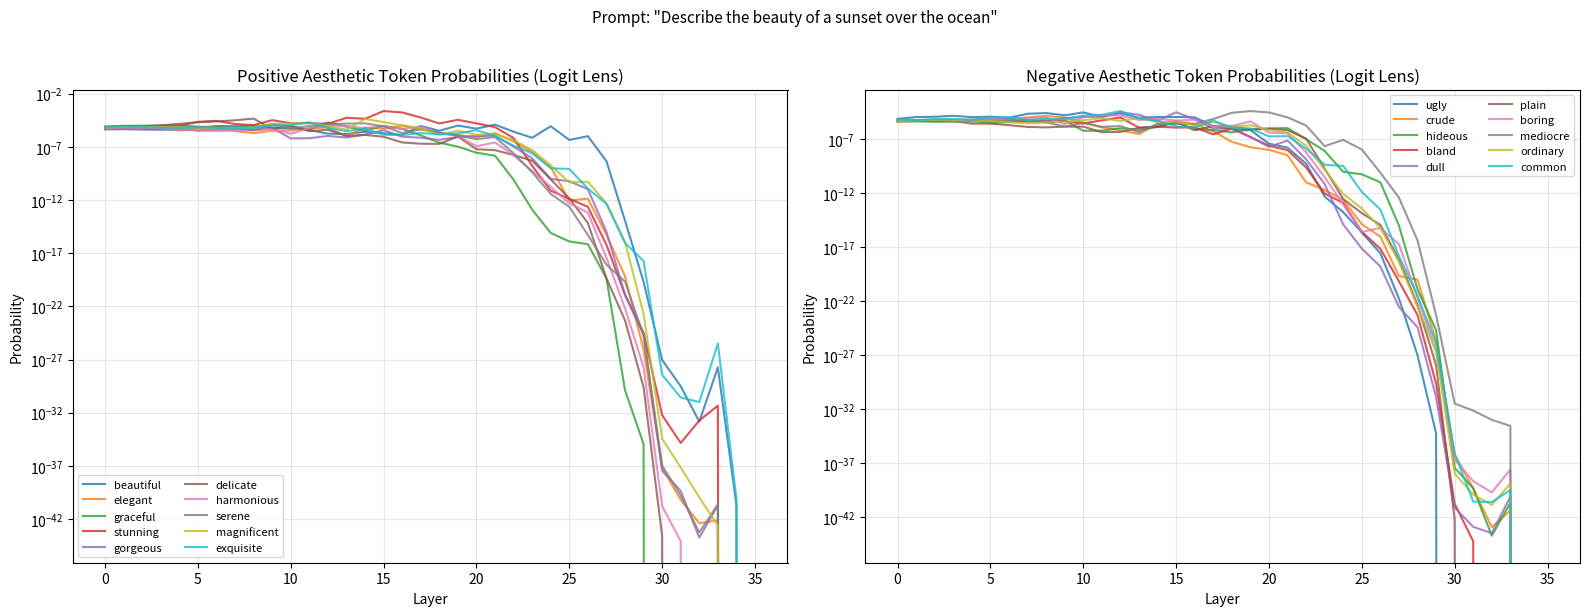

In [19]:
# Plot: Aesthetic vs Non-aesthetic token probability trajectories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Aesthetic tokens
for w in AESTHETIC_TOKENS:
    if w in aesthetic_probs:
        axes[0].plot(aesthetic_probs[w], label=w, alpha=0.8)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Probability')
axes[0].set_title('Positive Aesthetic Token Probabilities (Logit Lens)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Right: Non-aesthetic tokens
for w in NON_AESTHETIC_TOKENS:
    if w in aesthetic_probs:
        axes[1].plot(aesthetic_probs[w], label=w, alpha=0.8)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Probability')
axes[1].set_title('Negative Aesthetic Token Probabilities (Logit Lens)')
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.suptitle(f'Prompt: "{test_aesthetic}"', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'logit_lens_aesthetic.png', dpi=150, bbox_inches='tight')
plt.show()

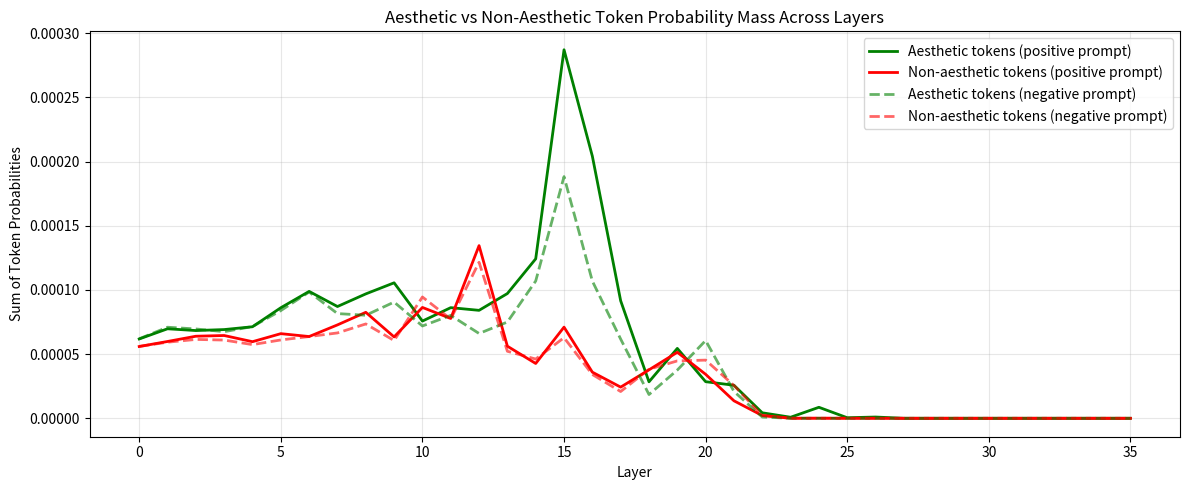


Aesthetic/Non-aesthetic ratio exceeds 2.0 at layer: 14


In [20]:
# Aggregate: sum of aesthetic vs non-aesthetic token probs per layer
sum_aesthetic = np.zeros(N_LAYERS)
sum_non_aesthetic = np.zeros(N_LAYERS)

for w in AESTHETIC_TOKENS:
    if w in aesthetic_probs:
        sum_aesthetic += aesthetic_probs[w]
for w in NON_AESTHETIC_TOKENS:
    if w in aesthetic_probs:
        sum_non_aesthetic += aesthetic_probs[w]

# Also run on a negative prompt for comparison
test_negative = 'Describe a dirty alley with dumpsters and puddles'
messages_neg = [{'role': 'user', 'content': test_negative}]
templated_neg = engine.apply_chat_template(messages_neg) + NOTHINK_SUFFIX
engine.reset()
engine.forward(templated_neg, add_special=True)
logit_neg = engine.logit_lens_all()
probs_neg = utils.softmax(logit_neg, axis=1)

sum_aesthetic_neg = sum(probs_neg[:, aesthetic_token_ids[w]] for w in AESTHETIC_TOKENS if w in aesthetic_token_ids)
sum_non_aesthetic_neg = sum(probs_neg[:, non_aesthetic_token_ids[w]] for w in NON_AESTHETIC_TOKENS if w in non_aesthetic_token_ids)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sum_aesthetic, '-', c='green', linewidth=2, label='Aesthetic tokens (positive prompt)')
ax.plot(sum_non_aesthetic, '-', c='red', linewidth=2, label='Non-aesthetic tokens (positive prompt)')
ax.plot(sum_aesthetic_neg, '--', c='green', linewidth=2, label='Aesthetic tokens (negative prompt)', alpha=0.6)
ax.plot(sum_non_aesthetic_neg, '--', c='red', linewidth=2, label='Non-aesthetic tokens (negative prompt)', alpha=0.6)
ax.set_xlabel('Layer')
ax.set_ylabel('Sum of Token Probabilities')
ax.set_title('Aesthetic vs Non-Aesthetic Token Probability Mass Across Layers')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'logit_lens_aggregate.png', dpi=150)
plt.show()

# Find divergence layer
ratio = sum_aesthetic / (sum_non_aesthetic + 1e-10)
diverge_layer = np.argmax(ratio > 2.0) if np.any(ratio > 2.0) else -1
print(f'\nAesthetic/Non-aesthetic ratio exceeds 2.0 at layer: {diverge_layer}')

## 11. Quick Steering Validation

Final sanity check: apply the aesthetic direction as a steering vector. If the subspace is real, positive steering should make output more "beautiful" and negative steering more "plain".

In [21]:
# Steering test
steer_prompt = 'Describe a garden'
messages = [{'role': 'user', 'content': steer_prompt}]
templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX

steer_layer = best_cls_layer  # use layer with best classification
steer_vec = aesthetic_direction[steer_layer]

results_steer = {}

# Baseline (no steering)
engine.reset()
engine.clear_interventions()
baseline = engine.generate(templated, max_tokens=200)
results_steer['baseline'] = baseline

# Positive steering (more aesthetic)
for strength in [1.0, 3.0, 5.0, 10.0]:
    engine.reset()
    engine.clear_interventions()
    engine.apply_steering(steer_layer, steer_vec, strength)
    output = engine.generate(templated, max_tokens=200)
    engine.clear_interventions()
    results_steer[f'+{strength}'] = output

# Negative steering (less aesthetic)
for strength in [1.0, 3.0, 5.0]:
    engine.reset()
    engine.clear_interventions()
    engine.apply_steering(steer_layer, steer_vec, -strength)
    output = engine.generate(templated, max_tokens=200)
    engine.clear_interventions()
    results_steer[f'-{strength}'] = output

print(f'Steering layer: {steer_layer}')
print(f'Prompt: "{steer_prompt}"')
for key, text in results_steer.items():
    print(f'\n{"=" * 60}')
    print(f'Strength: {key}')
    print(f'{text[:300]}')

Steering layer: 16
Prompt: "Describe a garden"

Strength: baseline
A garden is a carefully cultivated space, often filled with beauty, serenity, and life. It can be as small as a window box on a balcony or as vast as a sprawling estate, but no matter its size, it holds a special place in the hearts of many.

In a garden, you might find a variety of plants—flowers, 

Strength: +1.0
A garden is a carefully cultivated space where nature and human care intertwine to create a serene and beautiful environment. It can be as small as a window box or as vast as an estate, but no matter its size, a garden is a place of peace, growth, and wonder.

At first glance, a garden might be a ta

Strength: +3.0
A garden is a serene and enchanting space where nature and human care intertwine in perfect harmony. It is a sanctuary of beauty, where the gentle whispers of the wind and the soft rustle of leaves create an atmosphere of peace and contemplation. The earth, rich and fertile, cradles an array of pla

In [22]:
# Count aesthetic vocabulary in steered outputs
AESTHETIC_WORDS = set(['beautiful', 'elegant', 'graceful', 'stunning', 'gorgeous',
    'delicate', 'harmonious', 'serene', 'magnificent', 'exquisite', 'lovely',
    'splendid', 'radiant', 'pristine', 'sublime', 'enchanting', 'majestic',
    'refined', 'breathtaking', 'luminous', 'vibrant', 'lush', 'golden',
    'glistening', 'bloom', 'blossom', 'fragrant', 'gentle', 'tranquil'])

print(f'{"Strength":>10} | {"Aesthetic Words":>15} | {"Total Words":>12} | {"Density":>8}')
print('-' * 60)

densities = {}
for key, text in results_steer.items():
    words = text.lower().split()
    aes_count = sum(1 for w in words if w.strip('.,!?;:') in AESTHETIC_WORDS)
    density = aes_count / max(len(words), 1)
    densities[key] = density
    print(f'{key:>10} | {aes_count:>15} | {len(words):>12} | {density:>8.3f}')

  Strength | Aesthetic Words |  Total Words |  Density
------------------------------------------------------------
  baseline |               2 |          155 |    0.013
      +1.0 |               3 |          157 |    0.019
      +3.0 |               7 |          156 |    0.045
      +5.0 |               3 |          161 |    0.019
     +10.0 |               2 |          161 |    0.012
      -1.0 |               0 |          133 |    0.000
      -3.0 |               0 |          145 |    0.000
      -5.0 |               0 |          146 |    0.000


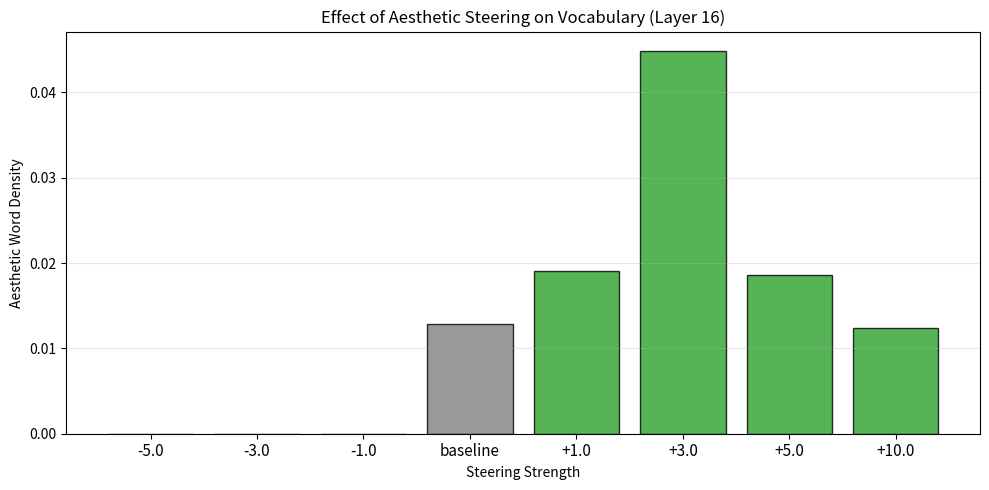

In [23]:
# Plot steering effect on aesthetic vocabulary density
keys_ordered = ['-5.0', '-3.0', '-1.0', 'baseline', '+1.0', '+3.0', '+5.0', '+10.0']
keys_present = [k for k in keys_ordered if k in densities]
vals = [densities[k] for k in keys_present]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if '-' in k else '#2ca02c' if '+' in k else 'gray' for k in keys_present]
ax.bar(range(len(keys_present)), vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(keys_present)))
ax.set_xticklabels(keys_present, fontsize=11)
ax.set_xlabel('Steering Strength')
ax.set_ylabel('Aesthetic Word Density')
ax.set_title(f'Effect of Aesthetic Steering on Vocabulary (Layer {steer_layer})')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'steering_aesthetic_density.png', dpi=150)
plt.show()

## 12. 2D Visualization — t-SNE / PCA Projection

Visualize the aesthetic subspace: do positive, negative, and neutral prompts form separable clusters?

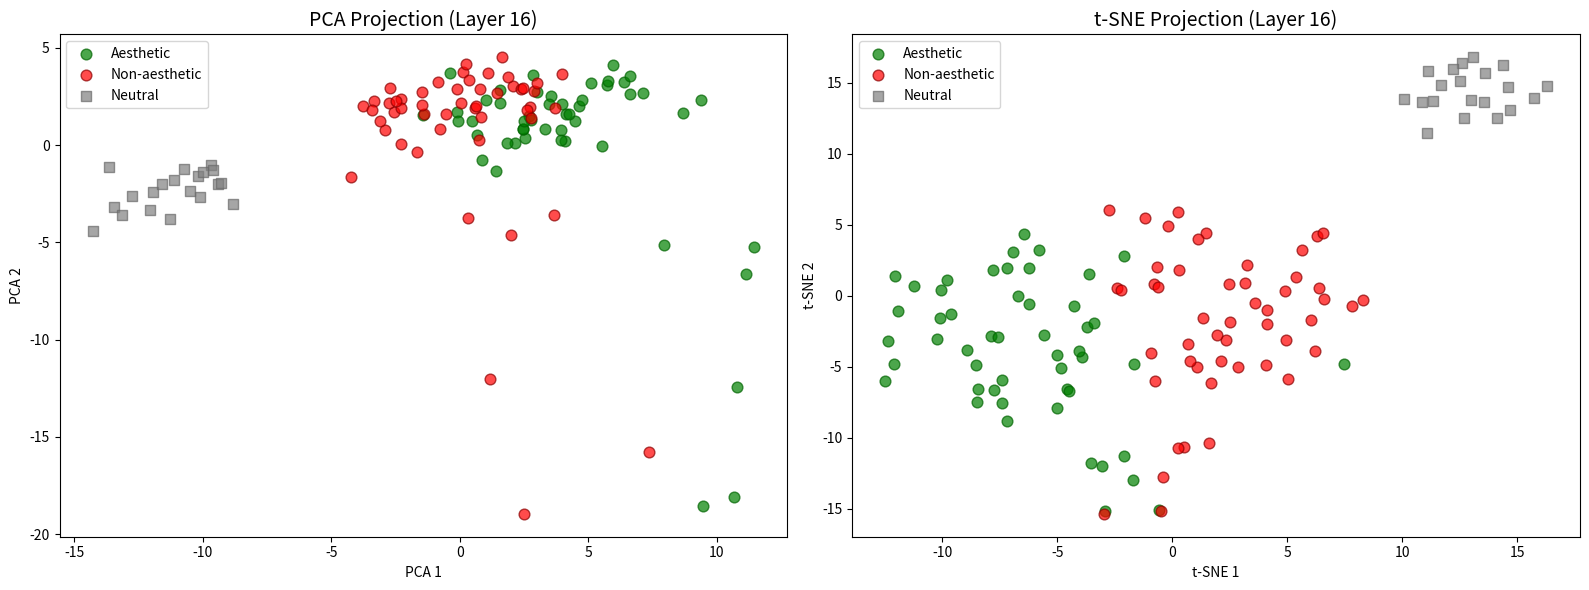


PCA explained variance: 0.346 (PC1+PC2)


In [24]:
analysis_layer = best_cls_layer

# Combine positive + negative activations at best layer
X_pos = acts_positive[:, analysis_layer]
X_neg = acts_negative[:, analysis_layer]
X_neu = acts_neutral[:, analysis_layer]
X_all = np.vstack([X_pos, X_neg, X_neu])
labels = ['Positive (aesthetic)'] * len(X_pos) + ['Negative (non-aesthetic)'] * len(X_neg) + ['Neutral'] * len(X_neu)

# Domain labels for coloring
domain_names = list(AESTHETIC_PROMPTS.keys())
domain_labels = []
for d in domain_names:
    domain_labels.extend([d] * 10)  # 10 positive per domain
for d in domain_names:
    domain_labels.extend([d] * 10)  # 10 negative per domain
domain_labels.extend(['neutral'] * len(X_neu))

# PCA projection
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_all)

# t-SNE projection
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=20, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_all)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_proj, title in [(axes[0], X_pca, 'PCA'), (axes[1], X_tsne, 't-SNE')]:
    n_pos = len(X_pos)
    n_neg = len(X_neg)
    n_neu = len(X_neu)
    
    ax.scatter(X_proj[:n_pos, 0], X_proj[:n_pos, 1], c='green', alpha=0.7, 
               label='Aesthetic', edgecolors='darkgreen', s=60)
    ax.scatter(X_proj[n_pos:n_pos+n_neg, 0], X_proj[n_pos:n_pos+n_neg, 1], c='red', alpha=0.7,
               label='Non-aesthetic', edgecolors='darkred', s=60)
    ax.scatter(X_proj[n_pos+n_neg:, 0], X_proj[n_pos+n_neg:, 1], c='gray', alpha=0.7,
               label='Neutral', edgecolors='dimgray', s=60, marker='s')
    
    ax.set_title(f'{title} Projection (Layer {analysis_layer})', fontsize=14)
    ax.legend(fontsize=10)
    ax.set_xlabel(f'{title} 1')
    ax.set_ylabel(f'{title} 2')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '2d_projection.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPCA explained variance: {pca_2d.explained_variance_ratio_[:2].sum():.3f} (PC1+PC2)")

## 13. Summary & Save Results

In [25]:
# ============================================================
# Save all results
# ============================================================
np.savez_compressed(
    OUTPUT_DIR / 'aesthetic_analysis_results.npz',
    # Directions
    aesthetic_direction=aesthetic_direction,
    aesthetic_direction_norm=aesthetic_direction_norm,
    # Classification
    layer_aucs=layer_aucs,
    layer_accs=layer_accs,
    best_cls_layer=best_cls_layer,
    # PCA
    explained_var_all=explained_var_all,
    # Domain similarity
    domain_sim_matrix=sim_matrix,
    domains=np.array(domains),
)

# Summary
print('=' * 60)
print('EXPERIMENT 1 SUMMARY: Mapping the Aesthetic Subspace')
print('=' * 60)
print(f'Model: Qwen3-8B Q4_K_M ({N_LAYERS} layers, {N_EMBD} hidden dim)')
print(f'Contrastive pairs: {n_pairs} (5 domains × 10 pairs)')
print(f'Neutral prompts: {len(NEUTRAL_PROMPTS)}')
print(f'')
print(f'--- Classification ---')
print(f'Best layer: {best_cls_layer}')
print(f'Best AUC:   {layer_aucs[best_cls_layer, 0]:.3f} ± {layer_aucs[best_cls_layer, 1]:.3f}')
print(f'Best Acc:   {layer_accs[best_cls_layer, 0]:.3f} ± {layer_accs[best_cls_layer, 1]:.3f}')
print(f'')
print(f'--- PCA (best layer) ---')
evr = explained_var_all[best_cls_layer]
print(f'PC1: {evr[0]:.3f}, Top-3: {sum(evr[:3]):.3f}, Top-5: {sum(evr[:5]):.3f}')
print(f'')
print(f'--- Cross-Domain Transfer (best layer) ---')
if best_cls_layer in transfer_results:
    for d in domains:
        print(f'  {d:>10}: AUC = {transfer_results[best_cls_layer][d]["auc"]:.3f}')
print(f'')
print(f'--- Domain Similarity ---')
off_diag = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
print(f'Mean inter-domain cosine: {off_diag.mean():.3f} (min={off_diag.min():.3f}, max={off_diag.max():.3f})')
print(f'')
print(f'Results saved to: {OUTPUT_DIR}')
print('=' * 60)

EXPERIMENT 1 SUMMARY: Mapping the Aesthetic Subspace
Model: Qwen3-8B Q4_K_M (36 layers, 4096 hidden dim)
Contrastive pairs: 50 (5 domains × 10 pairs)
Neutral prompts: 20

--- Classification ---
Best layer: 16
Best AUC:   1.000 ± 0.000
Best Acc:   1.000 ± 0.000

--- PCA (best layer) ---
PC1: 0.104, Top-3: 0.249, Top-5: 0.340

--- Cross-Domain Transfer (best layer) ---
      visual: AUC = 1.000
    auditory: AUC = 1.000
    literary: AUC = 1.000
      design: AUC = 1.000
   gustatory: AUC = 1.000

--- Domain Similarity ---
Mean inter-domain cosine: 0.612 (min=0.485, max=0.671)

Results saved to: /workspace/Data/aesthetic_experiment


In [26]:
# Cleanup
engine.clear_interventions()
engine.reset()
print('Engine reset. Ready for next experiment.')

Engine reset. Ready for next experiment.
